In [2]:
import qiskit


# ⚛️ Grover's Algorithm (The Quantum Search)

## 1. Theory: Finding the Needle in the Haystack

Imagine a database with $N$ items, completely unsorted. You are looking for one specific item (the "winner").

**The Challenge:**

* **Classical Computer:** It has to check items one by one. In the worst case, it checks every single item. On average, it takes $N/2$ tries. If you have 1 million items, it takes about 500,000 checks. ($O(N)$ time complexity).
* **Quantum Computer:** Grover's Algorithm can find the winning item in roughly $\sqrt{N}$ checks. For 1 million items, the quantum computer only needs about **1,000 checks**! This is a massive quadratic speedup.

**How it works (The Two-Step Dance):**
Grover's algorithm doesn't just run an Oracle; it uses a technique called **Amplitude Amplification**. It repeats two steps over and over:

1. **The Oracle (Phase Kickback):** The Oracle recognizes the winning item and flips its phase (makes it negative). It marks the winner, but if we measure now, the probability is still the same.
2. **The Diffuser (Inversion About the Mean):** This is the magic step. The Diffuser looks at all the amplitudes, calculates their average, and flips them around that average. Because the winner's phase was negative, this mathematical flip drastically *shrinks* the wrong answers and *amplifies* the winning answer!

For a 2-qubit system ($N=4$ possible states), we only need to run this dance **exactly 1 time** to reach a 100% success rate!

---

## 2. Code: Searching for the State $\vert{}11\rangle$

Let's build a 2-qubit Grover search to find the specific state `11` out of the four possibilities (`00`, `01`, `10`, `11`).




Grover's Algorithm Circuit (Searching for |11>):


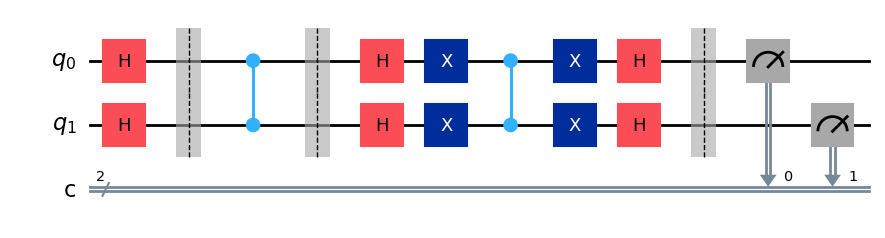

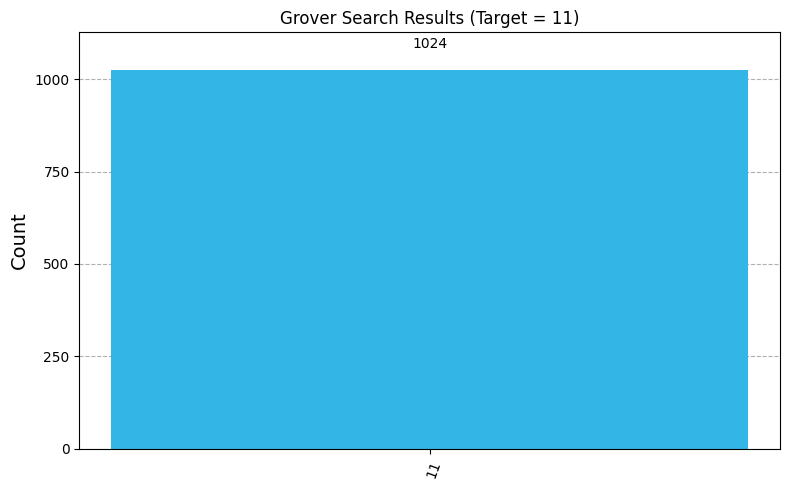

In [3]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

# --- Step 1: Initialize Circuit ---
# 2 qubits for our search space, 2 classical bits for measurement
qc = QuantumCircuit(2, 2)

# Create an equal superposition of all 4 states (|00>, |01>, |10>, |11>)
qc.h([0, 1])
qc.barrier()

# --- Step 2: THE ORACLE (Marking the Winner) ---
# We want to find |11>. 
# The Controlled-Z (CZ) gate perfectly flips the phase ONLY when both qubits are 1.
qc.cz(0, 1)
qc.barrier()

# --- Step 3: THE DIFFUSER (Amplitude Amplification) ---
# This specific sequence of gates performs the "Inversion about the Mean"
qc.h([0, 1])
qc.x([0, 1])
qc.cz(0, 1) # Another CZ acts as the multi-controlled Z for the diffuser
qc.x([0, 1])
qc.h([0, 1])
qc.barrier()

# --- Step 4: Measurement ---
qc.measure([0, 1], [0, 1])

# --- Visualize Circuit ---
print("Grover's Algorithm Circuit (Searching for |11>):")
display(qc.draw('mpl'))

# --- Simulate ---
sim = AerSimulator()
# Notice: shots=1024, but the Oracle was only applied ONCE in the circuit!
result = sim.run(qc, shots=1024).result()
counts = result.get_counts()

# --- Visualization ---
fig = plot_histogram(
    counts, 
    title="Grover Search Results (Target = 11)", 
    figsize=(8, 5), 
    color='#33b5e5' # The vibrant blue you like!
)
display(fig)




## 3. Exercises (Hands-on Practice)

### Exercise 1: Search for a Different Winner ($\vert{}00\rangle$)

**Goal:** Modify the Oracle to search for the state `00` instead of `11`.

* **Task:** The `cz` gate only marks `11`. To mark `00`, you need to "trick" the `cz` gate. Apply an `x` gate to both qubits *before* the `cz`, and then apply an `x` gate to both qubits *after* the `cz` to change them back.
* **Observation:** The Diffuser stays exactly the same! When you run the simulation, your histogram should show a 100% probability for the state `00`.

### Exercise 2: The Multi-Shot Reality

**Goal:** Understand what happens if we apply the Oracle/Diffuser dance too many times.

* **Task:** In your code, copy the lines for Step 2 (The Oracle) and Step 3 (The Diffuser), and paste them so that they run **twice** in a row before measurement.
* **Observation:** Run the circuit. You won't get 100% for `11` anymore! Grover's algorithm rotates the probability towards the winner, but if you rotate *too much*, you pass it and the probability goes back down. For 2 qubits, 1 iteration is perfect.

Bhai, taking it to 5 qubits is a massive leap! You are moving from a search space of 4 items to **32 items**.

This is exactly where Grover's Algorithm shows its true power. For a 2-qubit system, we only needed 1 iteration. But for larger systems, we have to repeat the "Oracle + Diffuser" dance multiple times to fully amplify the answer.


# ⚛️ Scaling Grover's Algorithm (The 5-Qubit Search)

## 1. Theory: The Iteration Math

When we increase the number of qubits to $n=5$, our total search space becomes $N = 2^5 = 32$ possible states (from `00000` to `11111`).

**How many iterations do we need?**
If we only run the Oracle and Diffuser once, the probability of finding the winner will increase slightly, but it won't be 100%. To get the maximum probability, the mathematical formula for the optimal number of iterations is:


$$\text{Iterations} \approx \frac{\pi}{4} \sqrt{N}$$

For 5 qubits ($N=32$):


$$\text{Iterations} \approx \frac{\pi}{4} \sqrt{32} \approx 0.785 \times 5.65 \approx 4.4$$

This means we need to repeat the Oracle and Diffuser **4 times** in a loop to get the highest possible chance of measuring the correct state!

---

## 2. Code: 5-Qubit Grover Search (Target = `11111`)

To build this, we need a **Multi-Controlled Z gate (MCZ)**. Since Qiskit doesn't have a native 5-qubit CZ gate, we build one by wrapping a Multi-Controlled X gate (`mcx`) between two H-gates on the target qubit.




5-Qubit Grover's Circuit (4 Iterations):


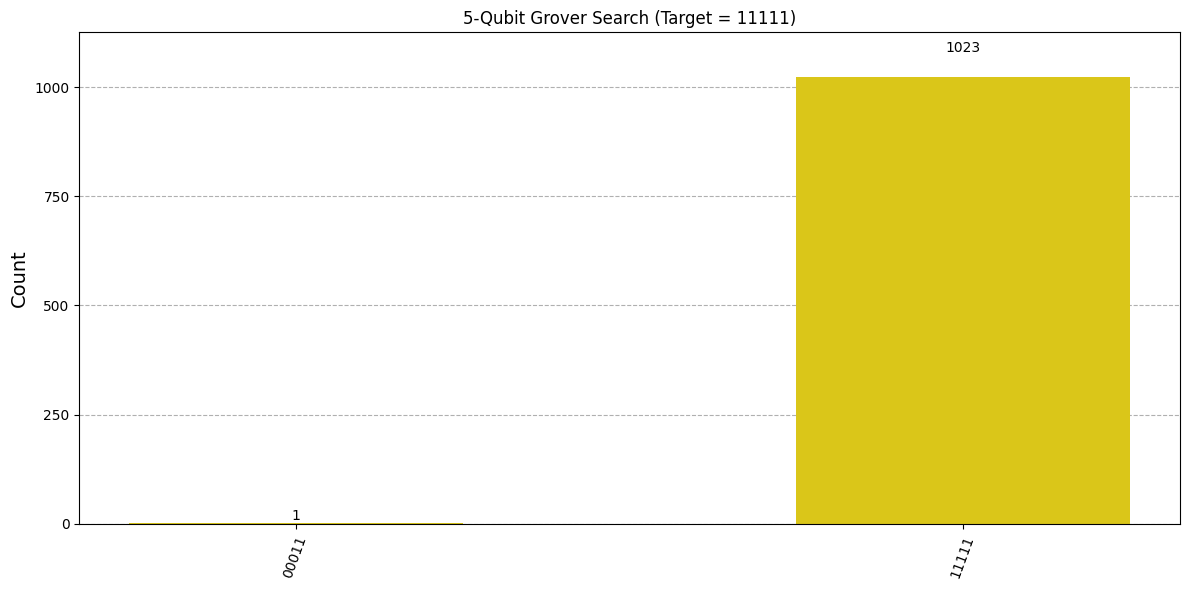

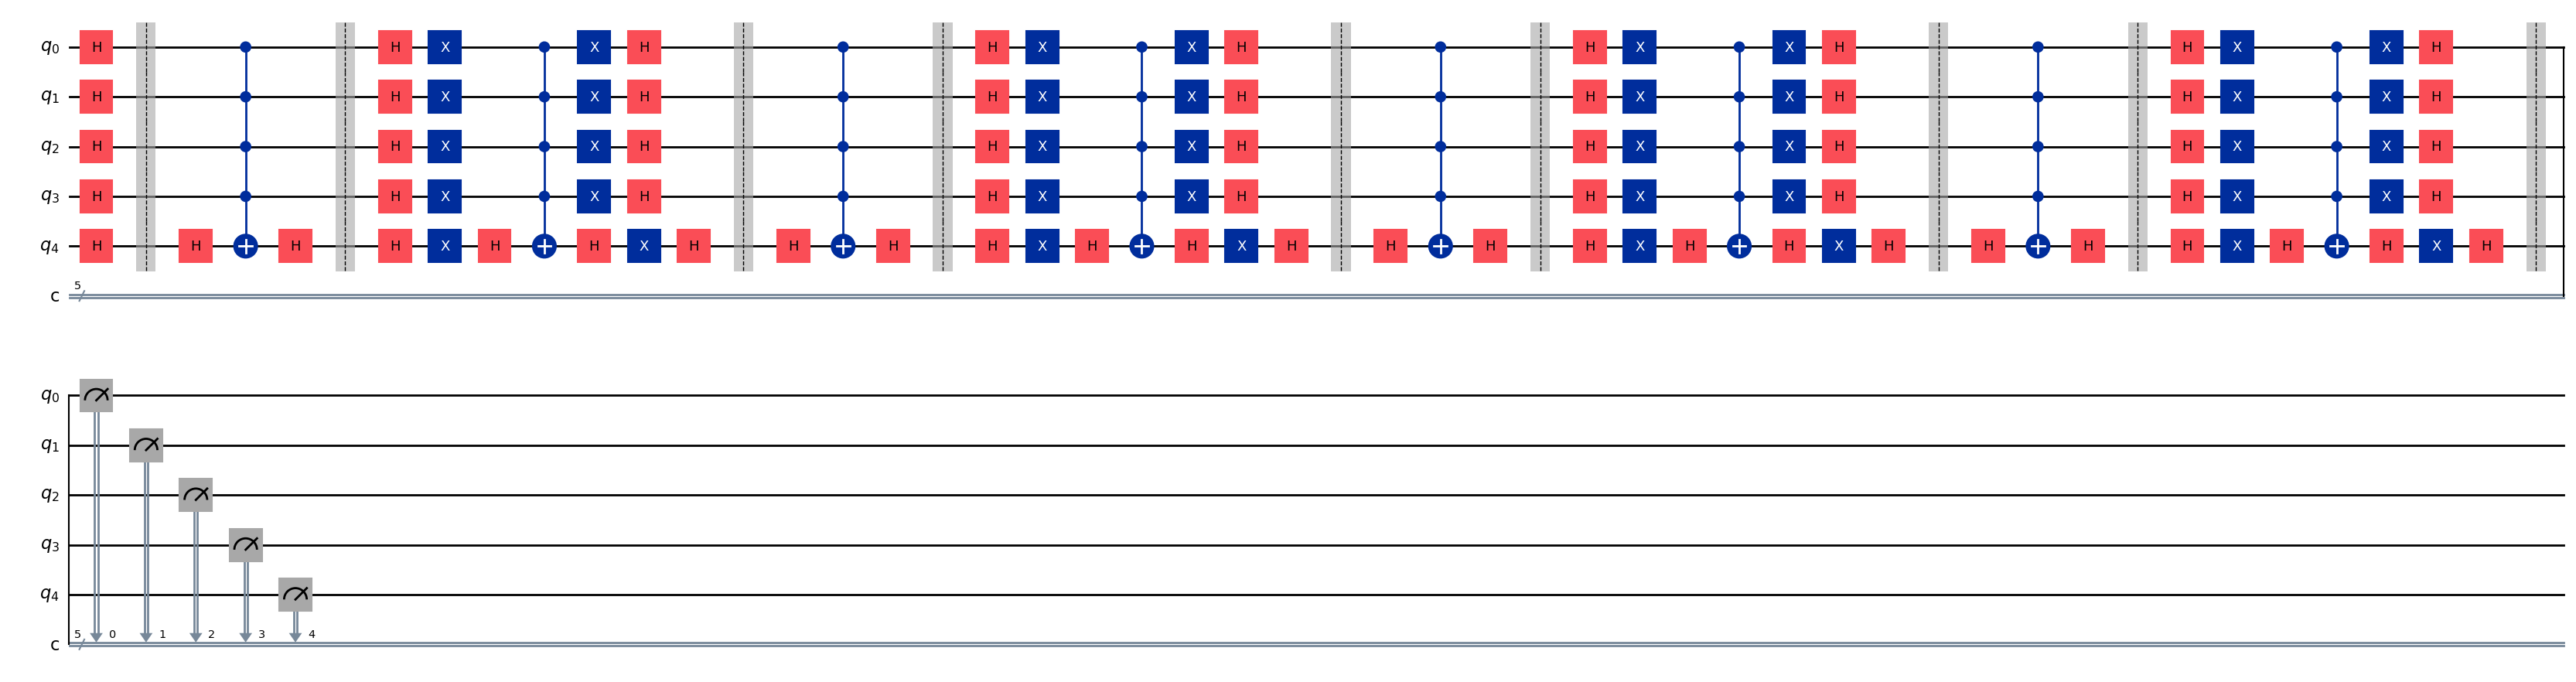

In [9]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
import math

n = 5 # Number of qubits
iterations = 4 # Optimal iterations for 5 qubits

# --- Step 1: Initialize Circuit ---
qc = QuantumCircuit(n, n)

# Put all 5 qubits into superposition
qc.h(range(n))

# --- THE GROVER LOOP ---
for step in range(iterations):
    qc.barrier()
    
    # --- Step 2: THE ORACLE (Marking |11111>) ---
    # We create a 5-qubit MCZ using H -> MCX -> H on the last qubit
    qc.h(n-1)
    qc.mcx(list(range(n-1)), n-1) # Multi-controlled X (Qubits 0,1,2,3 control Qubit 4)
    qc.h(n-1)
    
    qc.barrier()
    
    # --- Step 3: THE DIFFUSER ---
    qc.h(range(n))
    qc.x(range(n))
    
    # Multi-controlled Z (again, using H -> MCX -> H)
    qc.h(n-1)
    qc.mcx(list(range(n-1)), n-1)
    qc.h(n-1)
    
    qc.x(range(n))
    qc.h(range(n))

qc.barrier()

# --- Step 4: Measurement ---
qc.measure(range(n), range(n))

# --- Visualize Circuit ---
print(f"5-Qubit Grover's Circuit ({iterations} Iterations):")
# Note: For 5 qubits, the circuit drawing gets VERY wide. 
# You might want to use fold=False or just look at the results!
# display(qc.draw('mpl', fold=50)) 

# --- Simulate ---
sim = AerSimulator()
result = sim.run(qc, shots=1024).result()
counts = result.get_counts()

# --- Visualization ---
fig = plot_histogram(
    counts, 
    title="5-Qubit Grover Search (Target = 11111)", 
    figsize=(12, 6), 
    color="#dac619" 
)
display(fig)

display(qc.draw('mpl', fold=50))  # Display the circuit with folding for better visibility


---

## 3. Exercises (Hands-on Practice)

### Exercise 1: The Under-Rotated Search

**Goal:** Prove that the math formula for iterations is correct.

* **Task:** Change the `iterations` variable from **4** to **1**.
* **Observation:** Run the code. The probability for `11111` will no longer be at the top! It will be slightly higher than the others, but buried in noise. One step is not enough to "amplify" the signal in a 32-item database.

### Exercise 2: The Over-Rotated Search

**Goal:** See what happens when we "overshoot" the target.

* **Task:** Change the `iterations` variable to **8**.
* **Observation:** Run the code. You will see the probability of `11111` drop dramatically! Grover's algorithm is like a pendulum; if you push it too many times, it swings right past the target and goes back toward the wrong answers.

### Exercise 3: Change the Target

**Goal:** Modify the Oracle to find the state `00000`.

* **Task:** Just like we did in the 2-qubit version, apply `qc.x(range(n))` *before* the Oracle's MCZ gate block, and `qc.x(range(n))` *after* it. (Make sure this happens inside the `for` loop so it applies on every iteration!).


---

# ⚛️ Real-World Application: The RTO Database Heist

## 1. The Setup: 14-Qubit Architecture

To find vehicle record **9911**, our quantum computer needs to search a 14-qubit superposition space.

* **Total Search Space ($N$):** $2^{14} = 16384$ states.
* **Target:** Decimal 9911 (Binary: `10011010110111`).
* **Optimal Iterations:** $\frac{\pi}{4} \sqrt{16384} \approx 100$ iterations.

Instead of typing out the gates 100 times, we will create a **Compound Grover Block ($Q$)** containing our Oracle and Diffuser, convert it to a single quantum gate, and append it in a loop. Finally, we use `transpile()` to decompose this massive block so the `AerSimulator` can digest it without throwing faults.

## 2. Code: The Quantum Search & Speedup Visualization


Applying 100 Grover iterations...
Executing 14-qubit search on AerSimulator...

--- FORENSICS REPORT ---
Target Record: 9911
Quantum Measurement (Binary): 10011010110111
Decoded Decimal: 9911
SUCCESS: Vehicle record identified in a SINGLE shot!


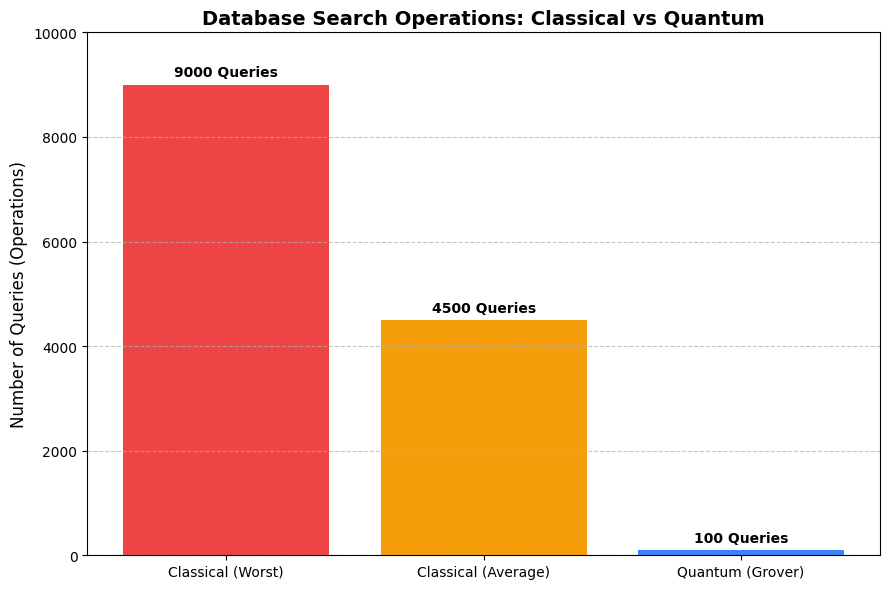

In [7]:
import math
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt

# --- 1. Problem Configuration ---
target_decimal = 9911
n_qubits = 14 # 2^14 = 16384, covers indices up to 9999
search_space = 2**n_qubits

# Format to 14-bit binary string (e.g., '10011010110111')
target_binary = format(target_decimal, f'0{n_qubits}b')

# --- 2. Build the Oracle ---
oracle = QuantumCircuit(n_qubits, name="Oracle")
# Qiskit orders qubits right-to-left. We flip '0' bits to isolate the target.
for i, bit in enumerate(reversed(target_binary)):
    if bit == '0':
        oracle.x(i)

# 14-Qubit Multi-Controlled Z (MCZ)
oracle.h(n_qubits - 1)
oracle.mcx(list(range(n_qubits - 1)), n_qubits - 1)
oracle.h(n_qubits - 1)

# Revert the X gates
for i, bit in enumerate(reversed(target_binary)):
    if bit == '0':
        oracle.x(i)

# --- 3. Build the Diffuser ---
diffuser = QuantumCircuit(n_qubits, name="Diffuser")
diffuser.h(range(n_qubits))
diffuser.x(range(n_qubits))

diffuser.h(n_qubits - 1)
diffuser.mcx(list(range(n_qubits - 1)), n_qubits - 1)
diffuser.h(n_qubits - 1)

diffuser.x(range(n_qubits))
diffuser.h(range(n_qubits))

# --- 4. Create Compound Grover Block (Q) ---
# --- 4. Create Compound Grover Block (Q) ---
grover_q = QuantumCircuit(n_qubits, name="Grover_Q")

# THE FIX: Explicitly convert the sub-circuits to gates first
oracle_gate = oracle.to_gate(label="Oracle")
diffuser_gate = diffuser.to_gate(label="Diffuser")

# Append the gates instead of the raw circuits
grover_q.append(oracle_gate, range(n_qubits))
grover_q.append(diffuser_gate, range(n_qubits))

# Now this will convert without throwing a QiskitError!
grover_gate = grover_q.to_gate(label="Grover_Block")
# --- 5. Main Quantum Circuit ---
qc = QuantumCircuit(n_qubits, n_qubits)
qc.h(range(n_qubits)) # Initial Superposition

# Calculate optimal iterations
iterations = math.floor((math.pi / 4) * math.sqrt(search_space))
print(f"Applying {iterations} Grover iterations...")

for _ in range(iterations):
    qc.append(grover_gate, range(n_qubits))

qc.measure(range(n_qubits), range(n_qubits))

# --- 6. Transpile & Execute (Shots = 1) ---
sim = AerSimulator()
# Transpile decomposes the custom Q block into simulator-friendly basis gates
transpiled_qc = transpile(qc, backend=sim)

print("Executing 14-qubit search on AerSimulator...")
result = sim.run(transpiled_qc, shots=1).result()
counts = result.get_counts()

# Decode result
binary_result = list(counts.keys())[0]
decoded_decimal = int(binary_result, 2)

print("\n--- FORENSICS REPORT ---")
print(f"Target Record: {target_decimal}")
print(f"Quantum Measurement (Binary): {binary_result}")
print(f"Decoded Decimal: {decoded_decimal}")

if decoded_decimal == target_decimal:
    print("SUCCESS: Vehicle record identified in a SINGLE shot!")

# --- 7. Plotting the Quadratic Speedup ---
# Let's compare the number of database queries (operations) needed
classical_worst = 9000
classical_avg = 4500
quantum_grover = iterations

labels = ['Classical (Worst)', 'Classical (Average)', 'Quantum (Grover)']
values = [classical_worst, classical_avg, quantum_grover]
colors = ['#ef4444', '#f59e0b', '#3b82f6']

plt.figure(figsize=(9, 6))
bars = plt.bar(labels, values, color=colors)

# Add value labels on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 100, f'{yval} Queries', 
             ha='center', va='bottom', fontweight='bold')

plt.title("Database Search Operations: Classical vs Quantum", fontsize=14, fontweight='bold')
plt.ylabel("Number of Queries (Operations)", fontsize=12)
plt.ylim(0, 10000)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
